---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import scipy.stats as stats

In [45]:
# read focus crime data
data = pd.read_csv('../data/sf_crime_merged_focus_2003_2025.csv')
data.head()
data["Focus Crime"].unique()

array(['Vehicle Theft', 'Assault', 'Missing Person', 'Fraud', 'Robbery',
       'Vandalism', 'Burglary', 'Drug Offense', 'Weapons', 'Prostitution'],
      dtype=object)

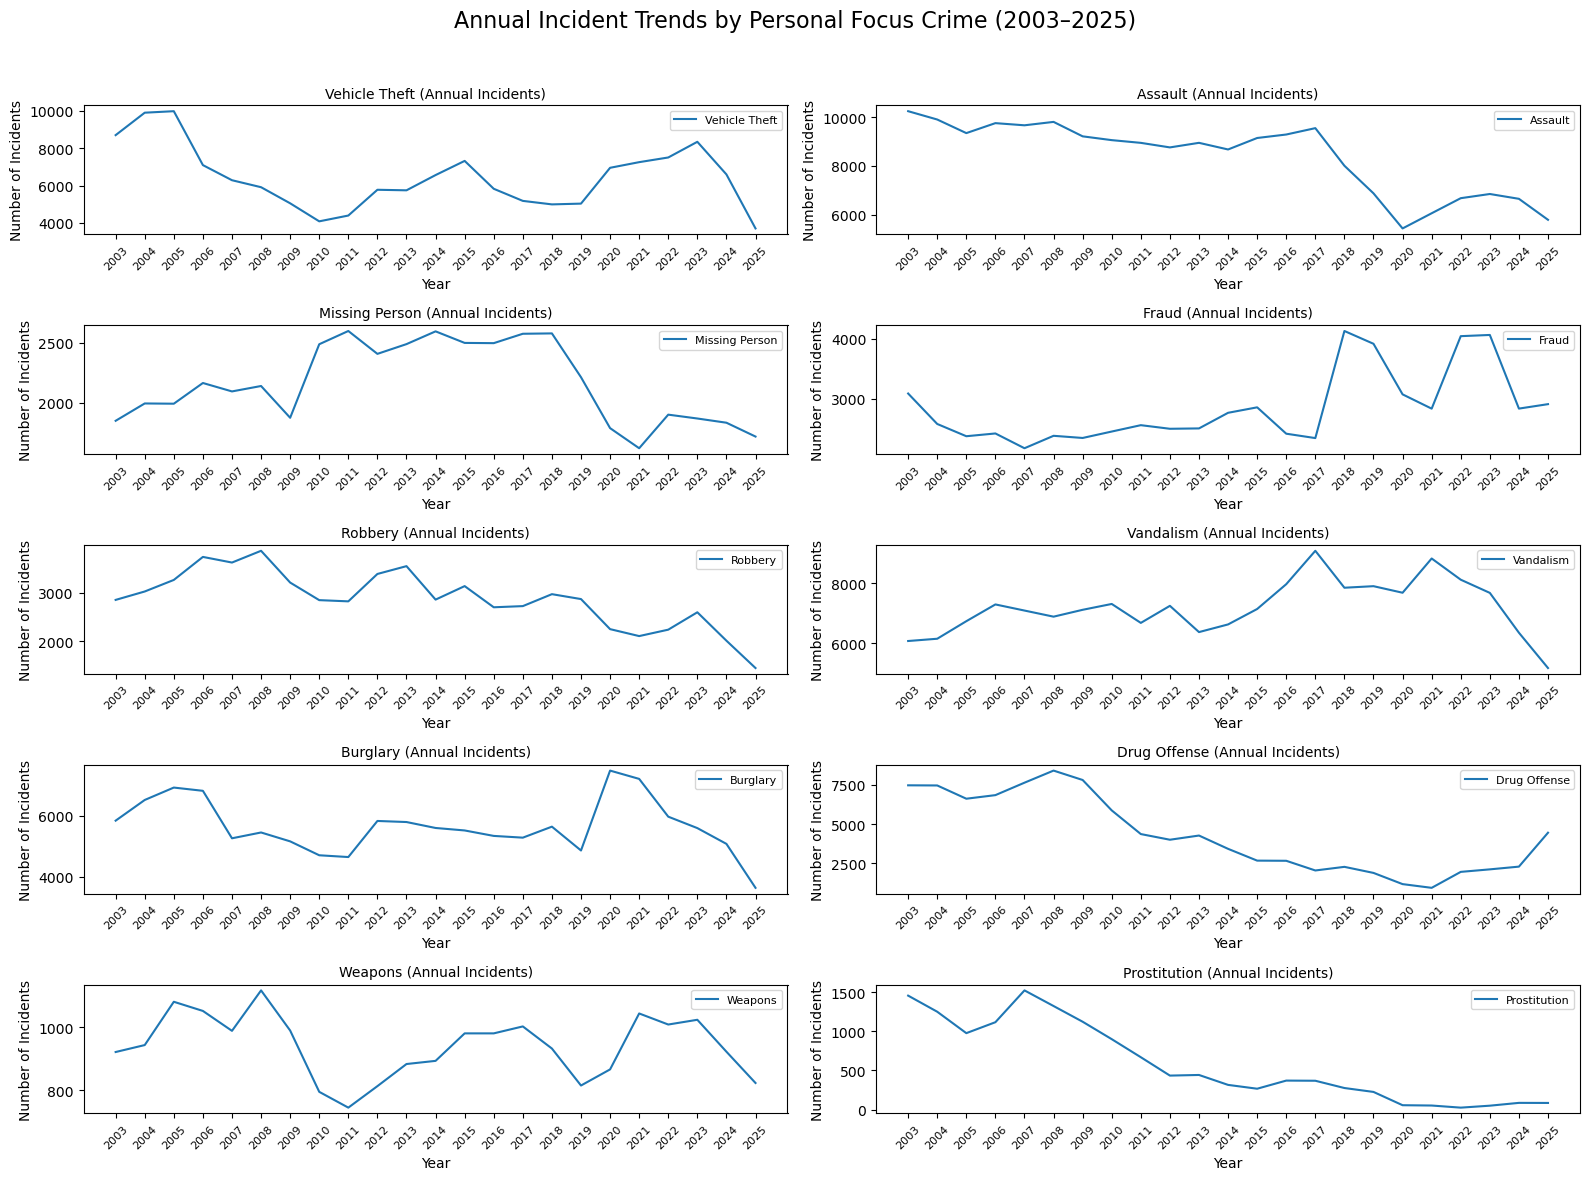

In [46]:
fig, axes = plt.subplots(5, 2, figsize=(16, 12), sharex=False, sharey=False)
axes = axes.flatten()

focus_crimes = data["Focus Crime"].unique()

# Parse to datetime to datetime
data["Incident Date"] = pd.to_datetime(data["Incident Date"])

# Don't include 2026
data = data[data["Incident Date"].dt.year != 2026]

# for loop to create a line graph for each focus crime
for ax, crime in zip(axes, focus_crimes):

    # Get counts of focus crime per year
    counts = (
        data[data["Focus Crime"] == crime]
        .groupby(data["Incident Date"].dt.year)
        .size()
    )

    counts.plot(ax=ax, label=crime)

    # Set every year on the x-axis
    years = counts.index
    ax.set_xticks(years) 
    ax.set_xticklabels(years, rotation=45, fontsize=8)

    ax.set_title(crime, fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Incidents")

    ax.legend(fontsize=8)

    ax.set_title(f"{crime} (Annual Incidents)", fontsize=10)

fig.suptitle("Annual Incident Trends by Personal Focus Crime (2003–2025)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Partial conclusion
It seems like most crimes have had ups and downs and especially during covid, however one notable thing is that drug offense and prostitution have been on a steep decline since around 2007-2008, a possible explanation for this would be decriminalizations for these crimes so fewer incidents are registered. 

Another notable feature is that during covid around 2019-2021, most crime types either happened dramatically less often like assault (probably due to social restrictions such), or followed their previous trend, however burglary actually went up quite a bit. A theory for why this could be the case is that during covid there was higher unemployment rate leaving people with reduced financial income. As a result of that, some individuals might have felt more financial pressure, which might have resulted in an increase of these types of crimes. 

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

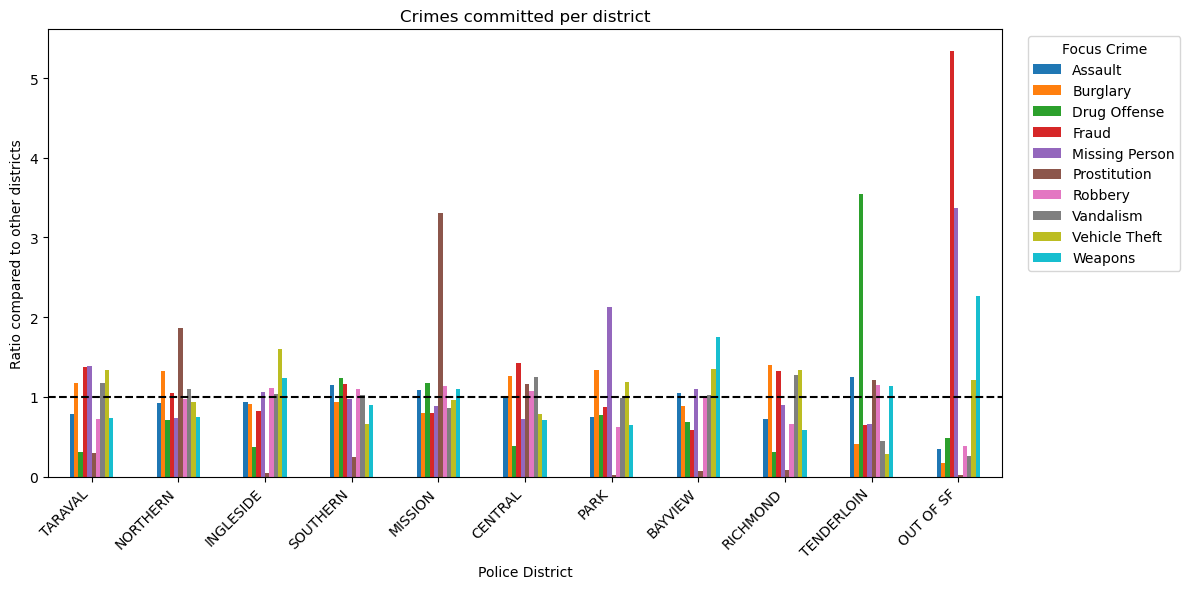

In [47]:
# Divide the count on each focus crime without the total count to get p(crime)
p_crime = data["Focus Crime"].value_counts() / len(data)

# initalize an empty array to keep track of each p(crime|district)
p_crime_district = []
for district in data["Police District"].str.upper().unique():
    # nr of total crimes in a district
    nr_of_total_crimes = len(data[data["Police District"].str.upper() == district])
    
    # nr of a focus crime in a district
    nr_of_crimes = data[data["Police District"].str.upper() == district]["Focus Crime"].value_counts()
    
    # Calculate p(crime|district) / p(crime) for each district
    p_crime_district.append((nr_of_crimes / nr_of_total_crimes) / p_crime)


# combine the data to a dataframe for plotting
df_combined = pd.concat(p_crime_district, axis=1)

# Assign district names as column labels
df_combined.columns = data["Police District"].str.upper().unique()

# Make sure the index is the crime names (optional but nice)
df_combined.index.name = "Focus Crime"

df_plot = df_combined.T

ax = df_plot.plot(kind="bar", figsize=(12, 6))

plt.axhline(y=1, color="black", linestyle="--", linewidth=1.5)

plt.xlabel("Police District")
plt.ylabel("Ratio compared to other districts")
plt.title("Crimes committed per district")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Focus Crime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Takeaway
We decided to visualize this with grouped bar charts, where each group is a police district and each bar in a group is a crime. We did that because you can easily see which crimes are over/under represented in a district just by looking at the district on the x-axis, as well as easily spot which how the representation of crimes differ per district.

The district we wanted to look at is Park. It has high overrepresentation of missing person compared to other district. Burglary and vehicle theft are also overrepresented in Park and prostitution is heavily underrepresented in Park.

According to https://www.sanfranciscopolice.org/stations/park-station the neighbourhoods included in Park are the vast eastern edge of Golden Gate Park and the world-famous neighborhoods of Haight-Ashbury and the Castro. Seeing as Golden Gate Park is part of that district, a theory to explain missing persons as well as vehicle theft, since there is a lot of people coming through there with their guard down. Regarding low prostitution rate compared to other districts, 4 districts that have higher prostitution and 2 of them way higher, so a theory could be that prostitution may concentrate in particular hotspot areas, and the Park district has no such area. 



---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

# Assignment 1.3: Visualizing Distributions

## Part A

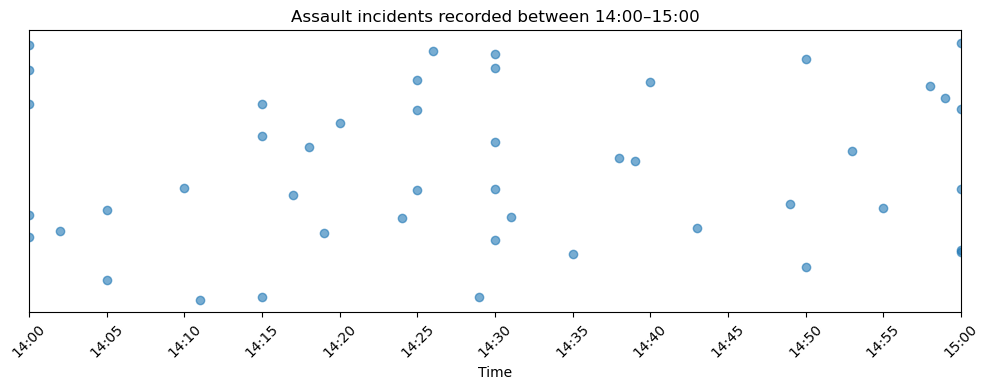

In [48]:
# part A
# only data for the last 4 months
new_data = data.loc[data["Focus Crime"].eq("Assault")].copy()
four_months_ago = pd.Timestamp.now() - pd.DateOffset(months=4)

new_data["Incident Date"] = pd.to_datetime(new_data["Incident Date"], errors="coerce")
new_data = new_data.loc[new_data["Incident Date"] >= four_months_ago].copy()

# Parse incident time to datetime (to use it as hours)
new_data["Incident Time"] = pd.to_datetime(
    "2000-01-01 " + new_data["Incident Time"].astype(str),
    errors="coerce"
)

# drop rows that don't have incident time
new_data = new_data.dropna(subset=["Incident Time"])

# using only data between 14 and 15, one hour interval
hour_start = pd.Timestamp("2000-01-01 14:00:00")
hour_end   = pd.Timestamp("2000-01-01 15:00:00")

one_hour = new_data[
    (new_data["Incident Time"] >= hour_start) &
    (new_data["Incident Time"] <= hour_end)
].copy()

# adds vertical jitter to point
def add_jitter(n, scale=0.2):
    return np.random.uniform(-scale, scale, size=n)

one_hour["jitter"] = add_jitter(len(one_hour))

# Plot
fig, ax = plt.subplots(figsize=(10,4))

ax.scatter(one_hour["Incident Time"], one_hour["jitter"], alpha=0.6)

ax.set_xlabel("Time")
ax.set_ylabel("")
ax.set_yticks([])

ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.set_xlim(hour_start, hour_end)

plt.title("Assault incidents recorded between 14:00–15:00")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Takeaway
From the jitter plot it can be seen that there do form clusters in 30 minute intervals and in some cases around a 5 minute interval, such as 14:40 and 14:25. From this we can assume that most incidents are registered at a time interval close to when the incident happen, and some up to 30 minutes. This means that the data is not 100% precise up to the minute so there needs to be caution when working with the incident times, especially if they need to be 100% precise.

## Part B

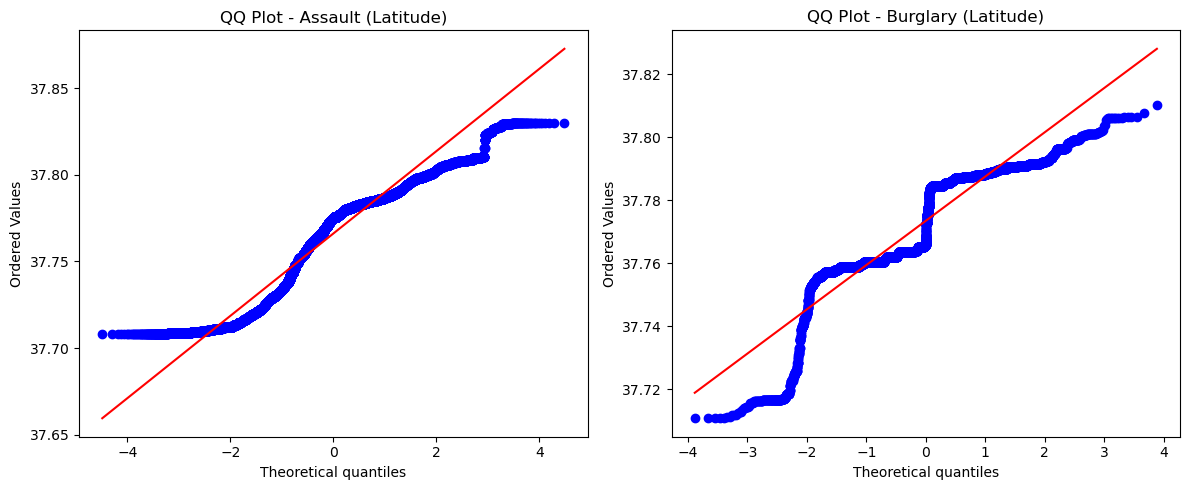

In [49]:
# Part B
# some values were 90, probably outliers, so only get ones under 50
data_clean = data[data["Latitude"] < 50]

# Look at assault and burglary
assault_lat = data_clean[data_clean["Focus Crime"] == "Assault"]["Latitude"]
burglary_lat = data_clean[data_clean["Focus Crime"] == "Prostitution"]["Latitude"]

# Create QQ plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Assault QQ plot
stats.probplot(assault_lat, dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot - Assault (Latitude)")

# Burglary QQ plot
stats.probplot(burglary_lat, dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot - Burglary (Latitude)")

plt.tight_layout()
plt.show()


### Takeaway
With the QQ plots we are comparing the latitude distribution of assault and prostitution to a normal distribution. 
The more that the data follows the line, the more normally distributed is it, so if it would lie perfectly on the line it would follow a perfect normal distribution. However that is not the case for assault nor prostitution, assault has a long flat line at the bottom which can be explained by Bayview, which has an overrepresentation of assault falling on that latitude line, then around 37.8 - 38.0 degrees there are a lot of assaults which could be explained the same way with districts that have comparitavely high assault rates such as tenderloin, mission and southern falling around this longitude. Lastly there is a flat line around 38.2 degrees which is exactly the longitude of treasure island which seems to have higher crime rates compared to other neighbourhoods https://www.doorprofit.com/crime-map/city/san_francisco-CA/neighborhood/treasure-island/

The distribution of prostitution follows the same pattern and has 3 distinct lines. Around 37.70 degrees, 37.76 degrees and 37.78-37.80 degrees. When looking at section 1.2 we can see that districts where prostitution is overrepresented fall on directly on these latitude lines, Mission district at 37.76, Northern district and Tenderloin at 37.78, Central district 37.798. Latitude numbers found on Google maps https://www.google.com/maps

So what this tells us about SF's crime geography is that it clusters and is concentrated in specific districts rather then being spreading evenly around the city.

## Part C

/var/folders/bx/4rwmxkgd60n55gr9cwq4np900000gn/T/ipykernel_1954/3258622351.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_data["Incident Time"] = pd.to_datetime(
/var/folders/bx/4rwmxkgd60n55gr9cwq4np900000gn/T/ipykernel_1954/3258622351.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(incident_times, labels=titles)


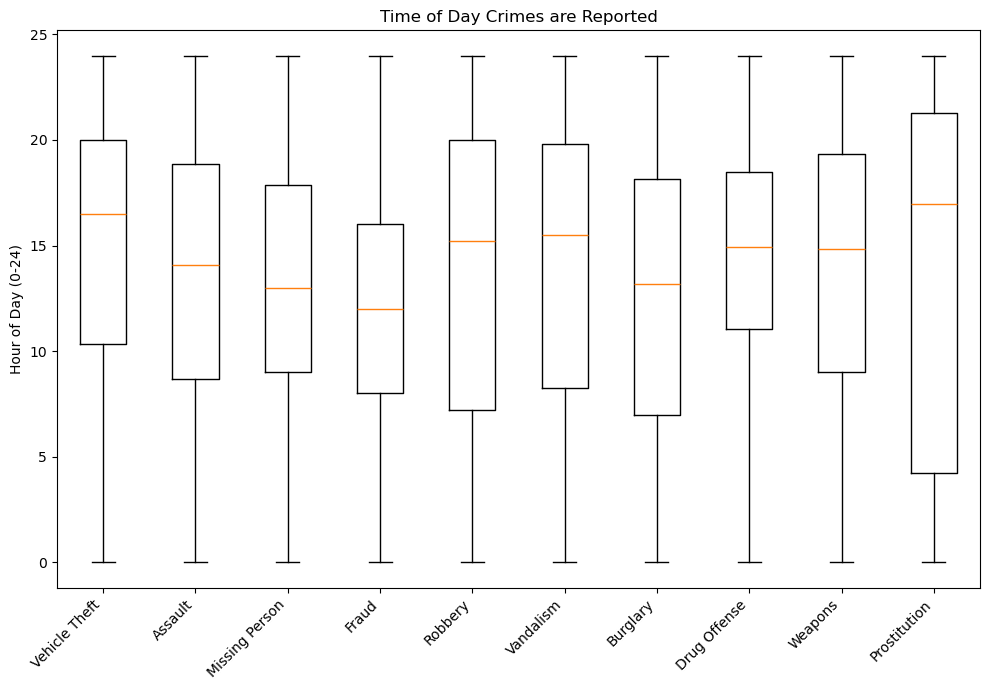

In [50]:
# part C
titles = []
incident_times = []

for crime in data["Focus Crime"].unique():
    crime_data = data[data["Focus Crime"] == crime].copy()
    crime_data["Incident Time"] = pd.to_datetime(
        "2000-01-01 " + crime_data["Incident Time"],
        errors="coerce"
    )
    
    # Convert to hours since midnight (numeric)
    numeric_times = (
        crime_data["Incident Time"].dt.hour +
        crime_data["Incident Time"].dt.minute / 60
    )
    incident_times.append(numeric_times)
    titles.append(crime)

fig = plt.figure(figsize=(10, 7))
plt.boxplot(incident_times, labels=titles)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Hour of Day (0-24)")
plt.title("Time of Day Crimes are Reported")
plt.tight_layout()
plt.show()

### Takeaway
The median for most crimes are around 12-18, although they happen all the way from 0-23:59, there are crimes that peak at night such as prostitution but the box plot does not handle the midnight wrap-around well, because crimes that happen during 23 PM and 1 AM stretch out the whole boxplot even though they are close together, which causes the median to go near the center.